In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import zipfile
import mapclassify
import folium
import re

file_path = r"C:\Users\jvkim\OneDrive\Desktop\California-Voting-District-Project"

tl_2025_06_tabblock20.zip from https://redistrictingdatahub.org/download/?datasetid=53726&document=%2Fweb_ready_stage%2Fvoterfile%2F2024+GEN+%26+PRI+Non-SPLC+States%2FCA_l2_2024_gen_stats_2020block.zip

In [8]:
with zipfile.ZipFile(file_path + r"\Data\ca_pl2020_official.zip") as ca_pl2020:
    ca_pl2020.extractall("Data")
    ca_pl2020.close()

In [9]:
ca_pl94 = pd.read_csv(file_path + r"\Data\state_PL94_2020_Adjusted_P24_DOJ_Block_csv\state_PL94_2020_Adjusted_P24_DOJ_Block.csv")
ca_blocks = gpd.read_file(file_path + r"\Data\tl_2025_06_tabblock20.zip")
ca_cd118 = pd.read_csv(file_path + r"\Data\06_CA_CD118.txt")
voter_file = pd.read_csv(file_path + r"\Data\CA_l2_2024_gen_stats_2020block\CA_l2_2024_gen_stats_2020block.csv")

C:\Users\jvkim\AppData\Local\Temp\ipykernel_20484\1444204787.py:4: DtypeWarning: Columns (0: geoid20) have mixed types. Specify dtype option on import or set low_memory=False.
  voter_file = pd.read_csv(file_path + r"\Data\CA_l2_2024_gen_stats_2020block\CA_l2_2024_gen_stats_2020block.csv")


<Axes: >

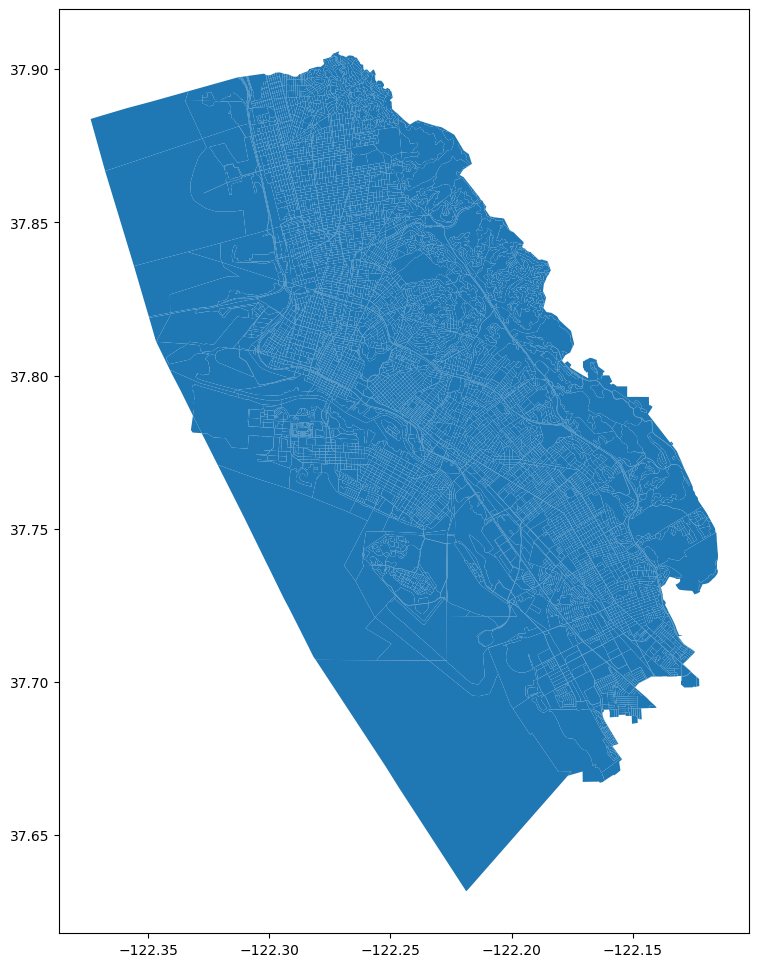

In [10]:
ca_blocks["GEOID20"] = ca_blocks["GEOID20"].astype(int)
ca_blocks_district = ca_blocks.merge(ca_cd118, left_on="GEOID20",right_on= "GEOID", how="left")

#ca_blocks_district[ca_blocks_district[" CDFP"] == 12].explore()
ca_blocks_district[ca_blocks_district[" CDFP"] == 12].plot(figsize=(20, 12))

Text(0.5, 1.0, "California's 12th Congressional District with Hispanic Proportion")

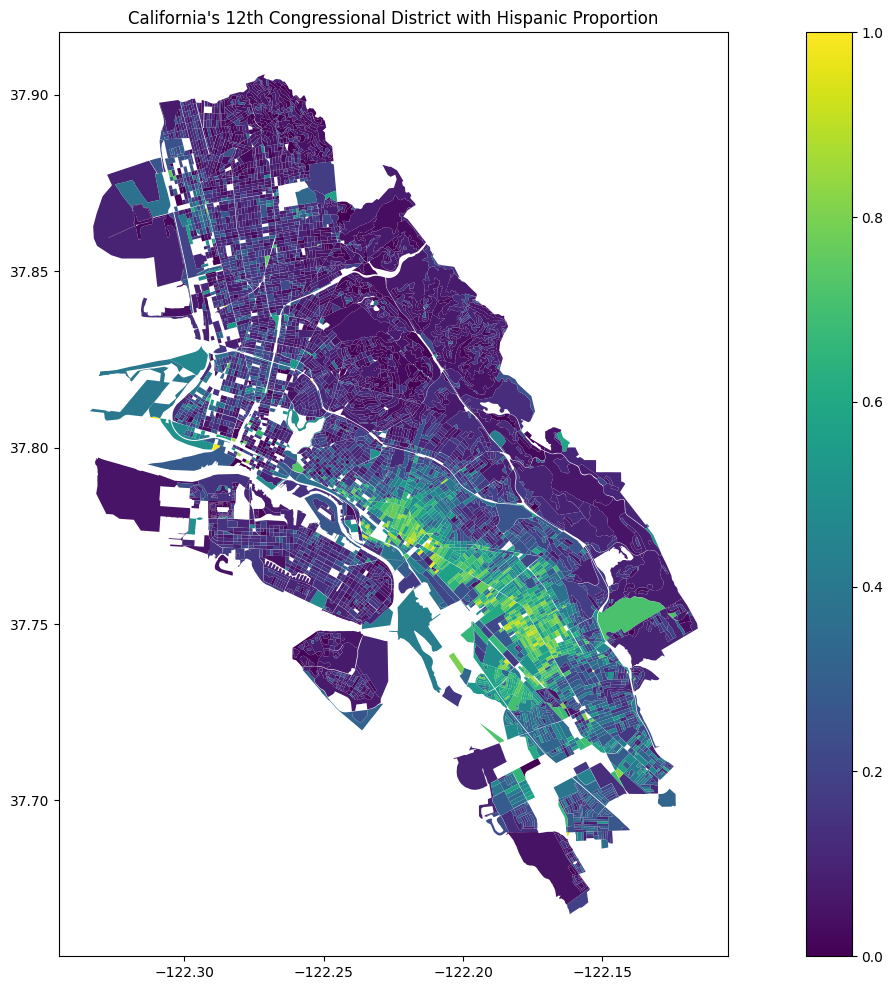

In [11]:
ca_block_demo = ca_blocks_district.merge(ca_pl94, left_on="GEOID20",right_on= "BLOCK20", how="left")
ca_block_demo_filtered = ca_block_demo[ca_block_demo["Population P2"]>0]
hispanic_12th = ca_block_demo_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin"," CDFP", "COUNTYFP20"]][ca_block_demo_filtered[" CDFP"] == 12]
hispanic_12th["Hispanic Proportion"] = hispanic_12th["Hispanic Origin"] / hispanic_12th["Population P2"]
#hispanic.explore("Hispanic Proportion")
hispanic_12th.plot("Hispanic Proportion", figsize=(20, 12), legend=True)
plt.title("California's 12th Congressional District with Hispanic Proportion")

Text(0.5, 1.0, "Distribution of Census Blocks in California's 12th District by Hispanic Proportion")

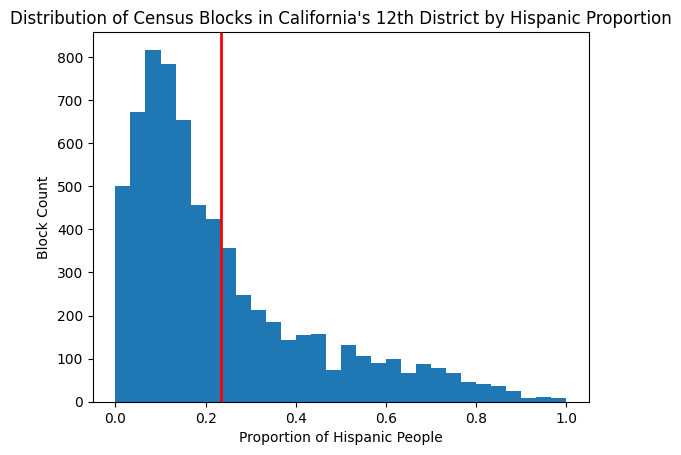

In [12]:
plt.hist(hispanic_12th["Hispanic Proportion"], bins = 30)
plt.axvline(np.average(hispanic_12th["Hispanic Proportion"]), linewidth=2, color='r')

plt.xlabel("Proportion of Hispanic People")
plt.ylabel("Block Count")
plt.title("Distribution of Census Blocks in California's 12th District by Hispanic Proportion")

In [ ]:
#Combines California demographic information by Congressional District
district_demo = ca_block_demo[["geometry", "Population P2", "Hispanic Origin"," CDFP"]].dissolve(by=" CDFP",aggfunc='sum')

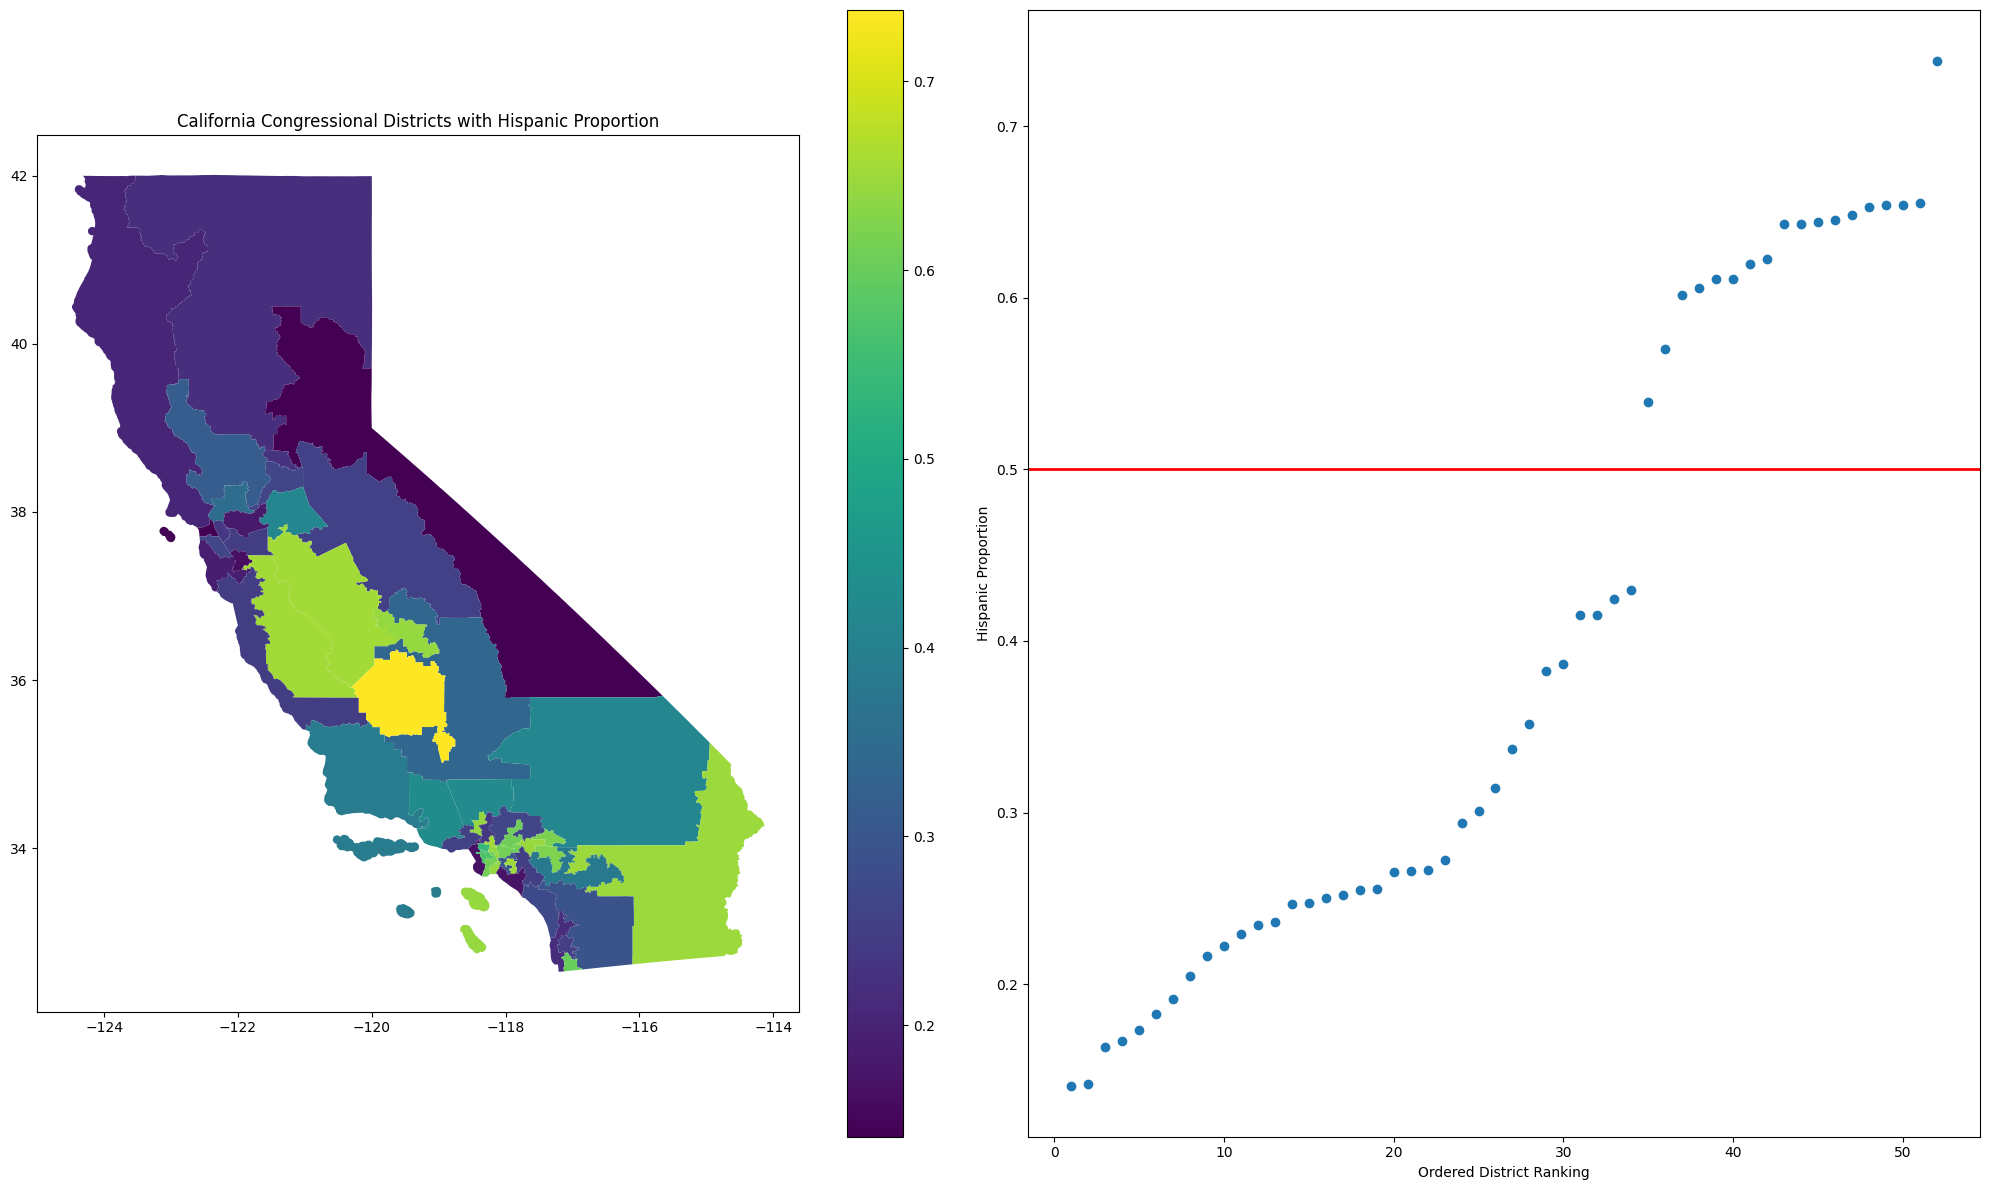

In [55]:
hispanic_district_demo = district_demo.copy()
hispanic_district_demo["Hispanic Proportion"] = hispanic_district_demo["Hispanic Origin"] / hispanic_district_demo["Population P2"]

fig, axs = plt.subplots(ncols=2, figsize=(20, 12))
hispanic_district_demo.plot("Hispanic Proportion", legend=True, ax=axs[0]) 
axs[0].set_title("California Congressional Districts with Hispanic Proportion")

plt.scatter(x=np.arange(1, 53, 1), y=hispanic_district_demo["Hispanic Proportion"].sort_values())
plt.axhline(0.5, linewidth=2, color='r')
axs[1].set_xlabel("Ordered District Ranking")
axs[1].set_ylabel("Hispanic Proportion")

plt.tight_layout()